In [9]:
import torch
import torchvision
import matplotlib
import os
import glob

In [10]:
print(torch.cuda.is_available())

True


## Kagglehub를 통한 데이터 다운로드 및 데이터 확인

In [7]:
!pip install kagglehub

In [8]:
import kagglehub



c:\Users\neo\miniconda3\envs\personal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Download latest version
path = kagglehub.dataset_download("ipythonx/mvtec-ad")

print("Path to dataset files:", path)

100%|██████████| 4.91G/4.91G [11:39<00:00, 7.53MB/s]  

Extracting files...


Path to dataset files: C:\Users\neo\.cache\kagglehub\datasets\ipythonx\mvtec-ad\versions\2


In [1]:
from pathlib import Path

print(Path.cwd())

c:\Users\neo\Desktop\seokjin\portfolio\notebooks


In [2]:
data_root = Path("datasets/transistor")

train_good_dir = data_root / "train" / "good"

print(train_good_dir.exists())

print(len(list(train_good_dir.glob("*.png"))))

True
213


## 이미지 한장을 열어서 눈으로 확인하는 단계

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
img_paths = sorted(train_good_dir.glob("*.png"))
img = Image.open(img_paths[0])

In [ ]:
print(img.size) # (가로,세로) 픽셀 크기 확인
print(img.mode) # RGB인지 RGBA인지를 확인하는 코드

(1024, 1024)
RGB


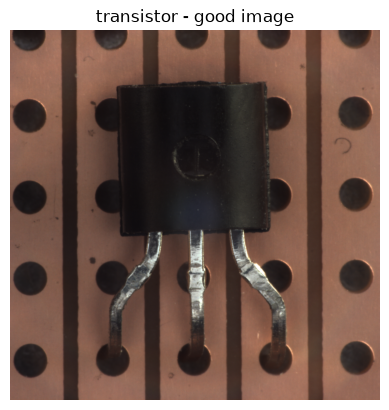

In [7]:
plt.imshow(img)
plt.title("transistor - good image")
plt.axis("off")
plt.show()

## Transform을 정의, 실제로 이미지에 적용하여 Tensor로 변환

In [ ]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((256,256)),
    torchvision.transforms.ToTensor() 
    # PIL 이미지의 픽셀값(0~255)을 0~1로 변환 & PIL의 (높이, 너비, 채널) 타입을 torch기반으로 [채널, 높이, 너비]로 변환
])


In [12]:
img_tensor = transform(img)

In [ ]:
print(img_tensor.shape) # [채널, 높이, 너비]
print(img_tensor.min())
print(img_tensor.max())

torch.Size([3, 256, 256])
tensor(0.0471)
tensor(1.)


## Tran Dataset 클래스

In [14]:
from torch.utils.data import Dataset

In [15]:
class TransistorTrainDataset(Dataset):
    def __init__(self,root_dir,transform = None):
        self.img_paths = sorted(root_dir.glob("*.png"))
        self.transform = transform
    
    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # 1. idx 첫번째 경로의 이미지를 PIL로 열기
        img = Image.open(self.img_paths[idx]) ## self.img 하지 않아도 됨 -> 현재 함수에서만 사용하고 끝
        # 2. transform 적용
        img_tensor = self.transform(img) ## self.img_tensor 하지 않아도 됨 -> 현재 함수에서만 사용하고 끝
        # 3. tensor 반환
        return img_tensor
    


- self 를 붙이면 instance 변수 (메서드 간에 공유 필요한 변수들을 self를 붙여서 선언)

## Dataset 인스턴스 검증

In [64]:
train_dataset = TransistorTrainDataset(
    root_dir = train_good_dir,
    transform= transform
)

In [65]:
print(len(train_dataset))

print(train_dataset[0].shape)
print(train_dataset[0].min())
print(train_dataset[0].max())

213
torch.Size([3, 256, 256])
tensor(0.0471)
tensor(1.)


- 즉 내가 선언한 TransistorTrainDataset 클래스가 실제 데이터셋에서 잘 적용되는지를 검증하는 단계

## DataLoader 검증

- 병렬처리를 위해 데이터를 묶음 단위로 묶어서 사용

In [18]:
from torch.utils.data import DataLoader

In [ ]:
loader = DataLoader(train_dataset,batch_size=16,shuffle=True)

In [ ]:
# 한 배치만 꺼내서 확인 -> 16으로 설정했으므로 16장의 배치가 등장
batch = next(iter(loader))

In [22]:
print(batch.shape)

torch.Size([16, 3, 256, 256])


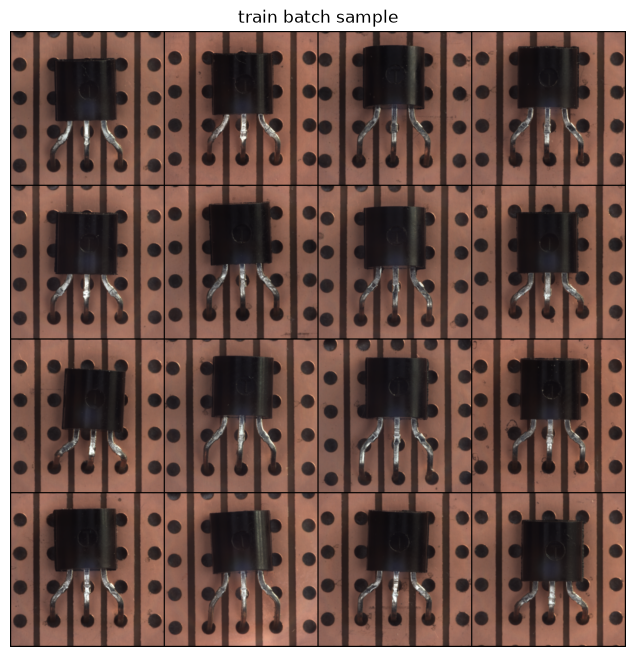

In [23]:
# 배치 이미지 시각화
grid = torchvision.utils.make_grid(batch,nrow=4)
plt.figure(figsize=(12,8))
plt.imshow(grid.permute(1,2,0)) # [채널, 높이, 너비] -> [높이, 너비, 채널]로 변경해야 plt가 인식
plt.axis("off")
plt.title("train batch sample")
plt.show()

## Test dataloader를 만들기 위한 과정

In [24]:
test_dir = data_root / "test"
gt_dir = data_root / "ground_truth"

In [27]:
test_categories = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])
print("test 폴더 목록 : ", test_categories)

test 폴더 목록 :  ['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']


In [41]:
## 각 폴더별 이미직 개수 확인
for cat in test_categories:
    img = list((test_dir / cat).glob("*.png"))
    print(f"{cat} : {img}")

bent_lead : [WindowsPath('datasets/transistor/test/bent_lead/000.png'), WindowsPath('datasets/transistor/test/bent_lead/001.png'), WindowsPath('datasets/transistor/test/bent_lead/002.png'), WindowsPath('datasets/transistor/test/bent_lead/003.png'), WindowsPath('datasets/transistor/test/bent_lead/004.png'), WindowsPath('datasets/transistor/test/bent_lead/005.png'), WindowsPath('datasets/transistor/test/bent_lead/006.png'), WindowsPath('datasets/transistor/test/bent_lead/007.png'), WindowsPath('datasets/transistor/test/bent_lead/008.png'), WindowsPath('datasets/transistor/test/bent_lead/009.png')]
cut_lead : [WindowsPath('datasets/transistor/test/cut_lead/000.png'), WindowsPath('datasets/transistor/test/cut_lead/001.png'), WindowsPath('datasets/transistor/test/cut_lead/002.png'), WindowsPath('datasets/transistor/test/cut_lead/003.png'), WindowsPath('datasets/transistor/test/cut_lead/004.png'), WindowsPath('datasets/transistor/test/cut_lead/005.png'), WindowsPath('datasets/transistor/test

In [30]:
## ground truth 
gt_categories = sorted([p.name for p in gt_dir.iterdir() if p.is_dir()])
print("ground truth 폴더 목록 : ", gt_categories)

ground truth 폴더 목록 :  ['bent_lead', 'cut_lead', 'damaged_case', 'misplaced']


## Test Dataset 구축
- `__init__`
test dataset은 4개의 폴더를 순회하면서 이미지 경로, 라벨, 마스크를 한번에 수집해야함.

- `__getitem__`
mask는 2가지 경우를 나눠서 처리
    - mask path가 None (good) : torch.zero(1,256,256) > 빈 mask를 생성
    - mask path가 있으면 (defect 이미지) : mask 이미지를 열어서 tensor로 변환

```python
class TransistorTestDataset(Dataset):
    def __init__(self,test_dir,gt_dir transform = None):
        self.labels = []
        # self.mask_paths = []
        
        for folder in test_dir.iterdir():
            for img_path in folder.name:
                self.img_paths = list(sorted(img_path.glob("*.png")))
                if self.img_paths.glob("good") :
                    self.labels.append(0)
                else :
                    self.labels.append(1)
                    self.mask_paths = [p for p in gt_dir.iterdir()]
```
- 처음작성코드 
    1. folder.name으로 받아버리면 문자열이라 이름하나하나의 문자열을 순회
    2. self.mask_paths를 저렇게 선언해버리면 중첩되서 덮어씌여짐.
    3. good인지 아닌지 판단을 하는 위치 잘못설정! > 폴더 이름으로 판단해야함!               

In [96]:
mask_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((256, 256), interpolation=torchvision.transforms.InterpolationMode.NEAREST),
    torchvision.transforms.ToTensor(),
])

In [97]:
class TransistorTestDataset(Dataset):
    def __init__(self,test_dir,gt_dir,transform = None,mask_transform = None):
        self.img_paths = []
        self.labels = []
        self.mask_paths = []
        self.transform = transform
        # 이미지 텐서에는 기존 transform을 사용해야 하므로, mask_transform을 새로 추가해줘야함!
        self.mask_transform = mask_transform
        
        for folder in test_dir.iterdir(): # 라벨링 작업은 폴더단위에서 판단해야함 > 하지만, 라베링 작업은 이미지단위에서 해줘야하므로, label만 결정하고 라벨링작업은 이미지 단위인 밑의 for문에서 실행해야함
            if folder.name == "good":
                label = 0
            else:
                label = 1
            for img_path in folder.glob("*.png"):
                self.img_paths.append(img_path)
                self.labels.append(label)
                
                if folder.name == "good":
                    self.mask_paths.append(None)
                else:
                    mask_path = gt_dir / folder.name / (img_path.stem + "_mask.png")
                    self.mask_paths.append(mask_path)
    def __len__ (self):
        return len(self.img_paths)
    
    def __getitem__(self,idx):
        img = Image.open(self.img_paths[idx])
        img_tensor = self.transform(img)

        label_tensor = torch.tensor(self.labels[idx])

        if self.mask_paths[idx] is None: #if self.mask_paths == None: 이렇게 하면 마스크 패스 리스트 전체와 비교하는 것
            mask_tensor = torch.zeros(1,256,256)
        else:
            mask = Image.open(self.mask_paths[idx]).convert("L")
            mask_tensor = self.mask_transform(mask)
            

        return img_tensor, label_tensor, mask_tensor

In [99]:
test_dataset = TransistorTestDataset(
    test_dir = test_dir,
    gt_dir = gt_dir,
    transform = transform,
    mask_transform = mask_transform
)

In [100]:
print(len(test_dataset))

100


In [101]:
img_tensor,label_tensor,mask_tensor = test_dataset[0]

In [102]:
print(img_tensor.shape)
print(label_tensor)
print(mask_tensor)

torch.Size([3, 256, 256])
tensor(1)
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


In [103]:
img_tensor,label_tensor,mask_tensor = test_dataset[10]

In [104]:
print(mask_tensor.unique())

tensor([0., 1.])


## AE(Encoder/Decoder)

- Encoder
`Conv2d` 레이어를 쌓아서 이미지를 압축시켜 나감. 
- Decoder
`ConvTranspose2d`를 사용해서 원래 크기로 복원

In [58]:
class AE(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),       
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=64,out_channels=32,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=32,out_channels=3,kernel_size=3,stride=2,padding=1),
            torch.nn.Sigmoid() # batchnorm + relu 대신 sigmoid가 와야함 >0~1사이의 값으로 출력해야하기때문

        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x    

In [59]:
model = AE()

dummy_input = torch.randn(1,3,256,256)
output = model(dummy_input)

In [60]:
print(dummy_input.shape)
print(output.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 241, 241])


- 두 값이 다르게 나옴 . > `ConvTranspose2d`의 출력크기 계산공식 때문 > 결론 `outputpadding `을 더해주면 됨

출력 크기 = (입력크기 - 1) * stride - 2 * padding + kernel_size

In [61]:
class AE(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),       
            torch.nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=2,padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),       
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=64,out_channels=32,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=32,out_channels=3,kernel_size=3,stride=2,padding=1,output_padding=1),
            torch.nn.Sigmoid() # batchnorm + relu 대신 sigmoid가 와야함 >0~1사이의 값으로 출력해야하기때문

        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x    

In [62]:
model = AE()

dummy_input = torch.randn(1,3,256,256)
output = model(dummy_input)

In [63]:
print(dummy_input.shape)
print(output.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


## 학습 루프

In [82]:
model = AE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()
loader = DataLoader(
    train_dataset,
    batch_size = 16,
    shuffle=True,
    num_workers=0,
    pin_memory=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # 모델은 데이터와 다르게 그냥 올려놓으면 됨
num_epochs = 10

In [83]:
for epoch in range(num_epochs):
    for batch in loader:
        # 1. gpu 올리기
        X= batch.to(device)
        # 2. forward pass
        outputs = model(X)
        # 3. loss 계산
        loss = loss_fn(outputs,X)
        # 4. optimizer.zero_grad()
        optimizer.zero_grad()
        # 5. loss.backward()
        loss.backward()
        # 6. optimizer.step()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss : {loss.item():.4f}")

Epoch 1/10, Loss : 0.0259
Epoch 2/10, Loss : 0.0118
Epoch 3/10, Loss : 0.0061
Epoch 4/10, Loss : 0.0037
Epoch 5/10, Loss : 0.0027
Epoch 6/10, Loss : 0.0024
Epoch 7/10, Loss : 0.0020
Epoch 8/10, Loss : 0.0019
Epoch 9/10, Loss : 0.0015
Epoch 10/10, Loss : 0.0016


- AE는 정답데이터가 없음. 그래서 loss 를 계산할 때는, model을 통과한 output과 X 자기 자신을 비교해서 loss를 계산.
- 지도학습처럼 라벨이 따로 존재하지 않고, `내가 넣은것과 얼마나 비슷하게 복원`하는지로 loss를 판별
- 애초에 train_dataset에서 `__getitem__`의 반환값이 이미지 tensor하나밖에 없음

In [75]:
print(torch.cuda.is_available())

True


## 평가모드

- Image AUROC : 해당 이미지가 정상인지 아닌지 확인하고 싶음 > 이미지 한장당의 평가
- Pixel AUROC : 이미지의 어느부분이 불량인지를 확인하고 싶음 > 픽셀 당의 평가

In [ ]:
model.eval()

img_tensor,label,mask_tensor= test_dataset[0]

img_tensor = img_tensor.unsqueeze(0).to(device) ##배치차원을 추가 [3,256,256] -> [1,3,256,256] 모델 자체가 [배치,채널, 높이, 너비]의 입력값을 기대함으로

In [85]:
with torch.no_grad():
    output = model(img_tensor)

print(output.shape)

torch.Size([1, 3, 256, 256])


`with X`
-  "X가 정의한 설정을 블록 시작할 때 켜고, 블록 끝나면(정상 종료든 에러든) 자동으로 원상복구"하는 패턴

### 하나의 이미지가지고 연습

In [86]:
print(img_tensor.shape)
print(output.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


In [88]:
error = (img_tensor - output)**2 ## 두 값의 차이의 제곱 계산

anomaly_map = error.mean(dim=1) # 오차를 채널별로 따로 계산한 다음, 채널차원을 평균내서 "흑백오차 맵"으로 변경

anomaly_score = anomaly_map.mean().item()

print(anomaly_map.shape)
print(anomaly_score)

torch.Size([1, 256, 256])
0.001585562014952302


In [89]:
anomaly_score_max = anomaly_map.max().item()

print(anomaly_score_max)

0.23391704261302948


### 실제 test 데이터셋에 적용

- 위에서 진행했던 이미지 한장에 대한 과정을 `모든 이미지에 대해 반복`하여

```python
anomaly_scores = [0.002, 0.15, 0.003, 0.21, ...]   # 각 이미지의 anomaly score
true_labels    = [0,     1,    0,     1,    ...]   # 각 이미지의 실제 라벨 (0=good, 1=defect)
```
이렇게 출력되도록.
`sklearn.metrics.roc_auc_score(true_labels,anomaly_scores)`에 넣으면 IMAGE AUROC값이 바로 계산.


- Pixel AUROC 
모든 픽셀의 오차값과 ground truth mask 값도 모아야함.

```python
pixel_scores = [픽셀1 오차, 픽셀2 오차, ...]   # 모든 이미지의 모든 픽셀을 펼친 것
pixel_labels = [픽셀1 mask값, 픽셀2 mask값, ...]  # 대응하는 ground truth
```

In [105]:
test_dataloader = DataLoader(test_dataset,batch_size = 16, shuffle=False,num_workers=0)

model.eval()

anomaly_scores = []
all_labels = []
pixel_scores = []
pixel_labels = []


with torch.no_grad():
    for img_tensor, label, mask_tensor in test_dataloader:
        img_tensor = img_tensor.to(device)
        output = model(img_tensor)

        error = (img_tensor - output)**2

        anomaly_map = error.mean(dim=1) # map을 만들때는 일단 RGB로 평균을 내는 것은 맞음. 그럼 현재 차원 [16,256,256]

        # anomaly_scores.append(anomaly_map.mean().item()) 
        ##이렇게 작성하면 batch의 값들을 하나의 평균값으로 만들어버림. > 하지만 우리가 원하는 건 16장의 각각의 score임
        
        ## 우리는 현재 [16,256,256]의 값이 존재하는 상황 ->[16]만 남겨둬야함.
        anomaly_score = anomaly_map.mean(dim=(1,2))
        anomaly_scores.extend(anomaly_score.cpu().numpy())

        all_labels.extend(label.numpy())

        pixel_scores.extend(anomaly_map.cpu().numpy().flatten())
        pixel_labels.extend(mask_tensor.numpy().flatten())

In [106]:
print(len(anomaly_scores))
print(len(all_labels))
print(len(pixel_scores))
print(len(pixel_labels))

100
100
6553600
6553600


## 결과값 계산

#### 처음 발생했던 에러
```python
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[94], line 2
      1 image_auroc = roc_auc_score(all_labels,anomaly_scores)
----> 2 pixel_auroc = roc_auc_score(pixel_labels,pixel_scores)

File c:\Users\neo\miniconda3\envs\personal\Lib\site-packages\sklearn\utils\_param_validation.py:218, in validate_params.<locals>.decorator.<locals>.wrapper(*args, **kwargs)
    212 try:
    213     with config_context(
    214         skip_parameter_validation=(
    215             prefer_skip_nested_validation or global_skip_validation
    216         )
    217     ):
--> 218         return func(*args, **kwargs)
    219 except InvalidParameterError as e:
    220     # When the function is just a wrapper around an estimator, we allow
    221     # the function to delegate validation to the estimator, but we replace
    222     # the name of the estimator by the name of the function in the error
    223     # message to avoid confusion.
    224     msg = re.sub(
    225         r"parameter of \w+ must be",
    226         f"parameter of {func.__qualname__} must be",
    227         str(e),
    228     )

File c:\Users\neo\miniconda3\envs\personal\Lib\site-packages\sklearn\metrics\_ranking.py:741, in roc_auc_score(y_true, y_score, average, sample_weight, max_fpr, multi_class, labels)
    733     return _average_binary_score(
    734         partial(_binary_roc_auc_score, max_fpr=max_fpr),
    735         y_true,
   (...)    738         sample_weight=sample_weight,
    739     )
    740 else:  # multilabel-indicator
--> 741     return _average_binary_score(
    742         partial(_binary_roc_auc_score, max_fpr=max_fpr),
    743         y_true,
    744         y_score,
    745         average,
    746         sample_weight=sample_weight,
    747     )

File c:\Users\neo\miniconda3\envs\personal\Lib\site-packages\sklearn\metrics\_base.py:74, in _average_binary_score(binary_metric, y_true, y_score, average, sample_weight)
     72 y_type = type_of_target(y_true)
     73 if y_type not in ("binary", "multilabel-indicator"):
---> 74     raise ValueError("{0} format is not supported".format(y_type))
     76 if y_type == "binary":
     77     return binary_metric(y_true, y_score, sample_weight=sample_weight)

ValueError: continuous format is not supported
```

- 현재 발생하는 문제. 
mask에 `transform`을 기존에 만들었던 transform 그대로 사용했는데,Resize의 기본 보간 방식은 BILINEAR(부드럽게 섞어서 리사이즈). 이미지에는 적합한 방식인데, mask는 원래 0과 1(또는 0과 255)만 있어야 하는 "이진 데이터"라서, BILINEAR로 리사이즈하면 경계 부분에서 0과 1이 섞여 0.3, 0.7 같은 중간값이 생김.

따라서
```python
mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])
```
mask_transform을 따로 만들어야함

In [107]:
from sklearn.metrics import roc_auc_score

In [108]:
image_auroc = roc_auc_score(all_labels,anomaly_scores)
pixel_auroc = roc_auc_score(pixel_labels,pixel_scores)

In [109]:
print(f"Image score : {image_auroc:.4f}")
print(f"Pixel score : {pixel_auroc:.4f}")

Image score : 0.4167
Pixel score : 0.5293


- 결과값이 너무 낮게 나옴 

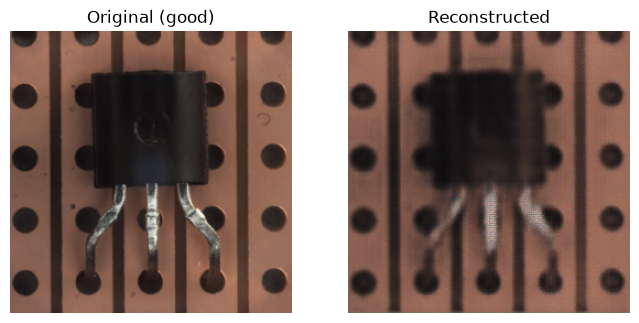

In [110]:
model.eval()

sample = train_dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(sample)

fig,axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(sample[0].cpu().permute(1,2,0))
axes[0].set_title("Original (good)")
axes[0].axis("off")

axes[1].imshow(recon[0].cpu().permute(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.show()

- 성능이 낮게 나오는 이유 및 검증하기. 

In [115]:
import numpy as np
anomaly_score_arr = np.array(anomaly_scores)
all_labels_arr = np.array(all_labels)

good_scores = anomaly_score_arr[all_labels_arr==0]
defect_scores = anomaly_score_arr[all_labels_arr==1]

print(f"Good 평균 scores : {good_scores.mean():.4f}")
print(f"Defect 평균 scores : {defect_scores.mean():.4f}")

Good 평균 scores : 0.0014
Defect 평균 scores : 0.0014


In [114]:
import numpy as np

anomaly_scores_arr = np.array(anomaly_scores)
all_labels_arr = np.array(all_labels)

good_scores = anomaly_scores_arr[all_labels_arr == 0]
defect_scores = anomaly_scores_arr[all_labels_arr == 1]

print(f"Good 평균 score: {good_scores.mean():.4f}")
print(f"Defect 평균 score: {defect_scores.mean():.4f}")

Good 평균 score: 0.0014
Defect 평균 score: 0.0014


- 현재 mean으로 평가했을때 결과가 좋지 않아서 max로 평가기준을 변경하고 확인.

In [116]:
anomaly_score_max = []

with torch.no_grad():
    for img_tensor, label, mask_tensor in test_dataloader:
        img_tensor = img_tensor.to(device)
        output = model(img_tensor)

        error = (img_tensor - output)**2

        anomaly_map = error.mean(dim=1) # map을 만들때는 일단 RGB로 평균을 내는 것은 맞음. 그럼 현재 차원 [16,256,256]

        # anomaly_scores.append(anomaly_map.mean().item()) 
        ##이렇게 작성하면 batch의 값들을 하나의 평균값으로 만들어버림. > 하지만 우리가 원하는 건 16장의 각각의 score임
        
        ## 우리는 현재 [16,256,256]의 값이 존재하는 상황 ->[16]만 남겨둬야함.
        anomaly_score = anomaly_map.amax(dim=(1,2))
        anomaly_score_max.extend(anomaly_score.cpu().numpy())

image_auroc_max = roc_auc_score(all_labels,anomaly_score_max)
print(f"Image AUROC (max) : {image_auroc_max:.4f}")

Image AUROC (max) : 0.5637


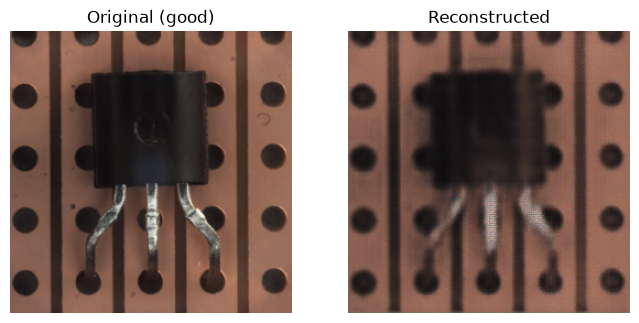

In [117]:
model.eval()

sample = train_dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(sample)

fig,axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(sample[0].cpu().permute(1,2,0))
axes[0].set_title("Original (good)")
axes[0].axis("off")

axes[1].imshow(recon[0].cpu().permute(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.show()

## 결과저장

### metrics 저장

In [120]:
print(os.getcwd())

c:\Users\neo\Desktop\seokjin\portfolio\notebooks


In [121]:
import json

metrics = {
    "model" : "AutoEncoder",
    "image_auroc" : image_auroc,
    "pixel_auroc" : pixel_auroc,
    "image_auroc_max_score" : image_auroc_max
}

with open("../results/metrics/autoencoder_metrics.json","w") as f:
    json.dump(metrics,f,indent = 4)

### 시각화 저장

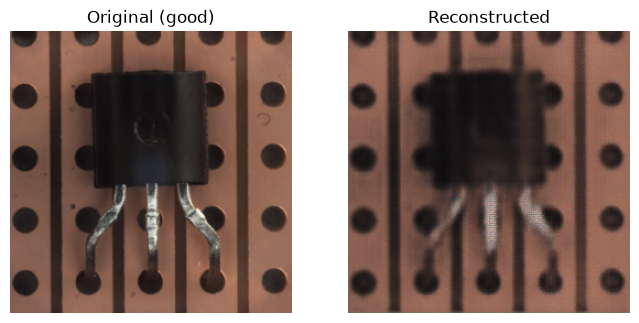

In [122]:
model.eval()

sample = train_dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(sample)

fig,axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(sample[0].cpu().permute(1,2,0))
axes[0].set_title("Original (good)")
axes[0].axis("off")

axes[1].imshow(recon[0].cpu().permute(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.savefig("../results/visualizations/reconstruction_good.png",bbox_inches="tight")
plt.show()

##### Defect이미지의 anomaly heatmap 저장 
- 원본이미지, 복원 이미지, 모델이 예측한 anomaly map, ground truth mask

```python
axes[].imshow(,permute(1,2,0))
```

permute : 차원의 순서를 바꿔줌. 
torch는 (채널, 높이, 너비) 순서로 받지만, plt는 (높이,너비, 채널) 순서로 받길 원함.
따라서 permute을 사용해서 plt가 원하는 순서의 인덱스 번호대로 바꿔줌.

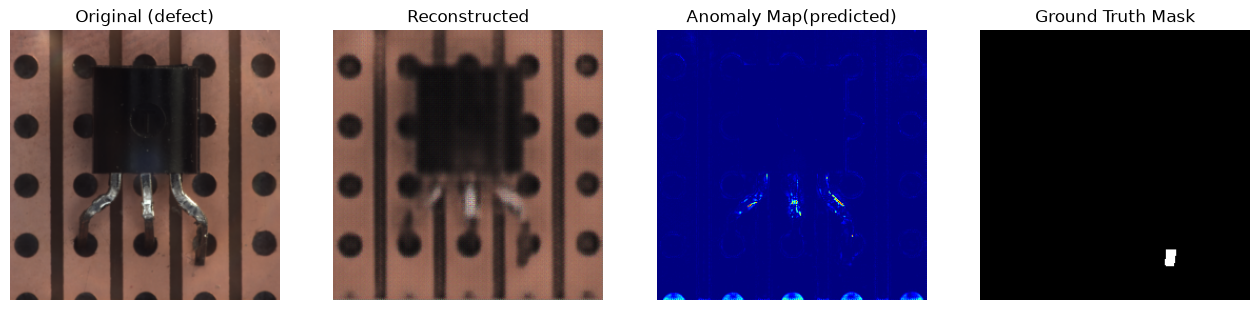

In [126]:
defect_idx = None
for i in range(len(test_dataset)):
    _,label,_ = test_dataset[i]
    if label == 1:
        defect_idx = 1
        break

img_tensor, label, mask_tensor = test_dataset[defect_idx]
img_input = img_tensor.unsqueeze(0).to(device)


with torch.no_grad():
    output = model(img_input)

error = (img_input- output)**2

anomaly_map = error.mean(dim=1)[0].cpu()

fig,axes = plt.subplots(1,4,figsize=(16,4))

axes[0].imshow(img_tensor.permute(1,2,0))
axes[0].set_title("Original (defect)")
axes[0].axis("off")

axes[1].imshow(output[0].cpu().permute(1,2,0))
# 배치 차원을 가지고 있어서 배치차원을 없애기 위해 인덱싱을 통해 배치 차원을 없애줌
axes[1].set_title("Reconstructed")
axes[1].axis("off")

axes[2].imshow(anomaly_map, cmap="jet")
axes[2].set_title("Anomaly Map(predicted)")
axes[2].axis("off")

axes[3].imshow(mask_tensor[0],cmap="gray") 
## mask_tensor는 원래 3차원 [1,256,256]. 즉, 채널의 차원이 남아 있어서 이걸 없애주려고. > plt가 이미지를 그릴때 2차원을 원함
## mask_tensor는 처음 선언할 때부터 2차원의 흑백이미지였기때문에.
axes[3].set_title("Ground Truth Mask")
axes[3].axis("off")

plt.savefig("../results/visualizations/anomaly_heatmap_examples.png",bbox_inches = "tight")
plt.show()


# AutoEncoder 기반 이상탐지 파이프라인

- 현재 autoencoder기반 이상탐지의 원인을 이미지로 살펴보면 다음과 같다. 정답 부분은 오른쪽에 빠져나온 부분이지만, 현재 학습해서 예측한 이미지를 heatmap으로 확인했을때 다리 전체를 이상값으로 탐지하여 판단하고 있는 걸로 보아, 현재 성능이 그다지 높지 않음을 확인할 수 있다.
다만, 성능을 높이기 위해 `AutoEncoder_develop.ipynb` 파일에서 실험을 한 결과, layer층을 더 깊게 쌓고, epoch횟수를 늘려나가면 성능이 점차 향상 되어감을 확인할 수 있음